In [1]:
import sys
import os
os.chdir('/zhome/71/c/146676/main/')
import time
import SimpleITK as sitk
import numpy as np
from astropy.io import fits
from helpers import module_auxiliary as ma
import tifffile
from multiprocessing import Pool
import matplotlib.pyplot as plt
from helpers import extended_data as ed
from cil.recon import FBP
#from cil.plugins.astra import FBP
from cil.framework import AcquisitionGeometry, AcquisitionData, ImageGeometry, ImageData, BlockDataContainer
from cil.plugins.ccpi_regularisation.functions import FGP_TV
from cil.optimisation.functions import L2NormSquared, L1Norm, BlockFunction, MixedL21Norm, IndicatorBox, TotalVariation, LeastSquares
from cil.optimisation.operators import BlockOperator, GradientOperator, IdentityOperator, FiniteDifferenceOperator
from cil.optimisation.algorithms import CGLS, SIRT, GD, FISTA, ISTA, PDHG, SPDHG
from cil.plugins.astra.operators import ProjectionOperator
from cil.optimisation.functions import IndicatorBox, MixedL21Norm, L2NormSquared, \
                                       BlockFunction, L1Norm, LeastSquares, \
                                       OperatorCompositionFunction, TotalVariation, \
                                       ZeroFunction
from cil.optimisation.operators import BlockOperator, GradientOperator,\
                                       GradientOperator
import h5py
from cil.utilities.display import show_geometry
from scipy.ndimage import uniform_filter1d
from cil.processors import Slicer
from scipy.interpolate import interp1d
import cv2
import hdf5plugin
from scipy.ndimage import uniform_filter
from scipy.ndimage import label, sum_labels
from cil.plugins.astra import ProjectionOperator
from scipy.ndimage import label

In [2]:
c0, c1 = [0, 2000]
y0,y1 = 130, 230

q_values = [80]
N_labels = 20
q_powder_strings = [f"crystal_q-{q}" for q in q_values]

recon = []

q_key = q_powder_strings[0]
with h5py.File('/work3/msaca/sliceA_DA_cache/integrated-0339.h5', 'r') as file:
    dataset2 = file[q_key][:]
data = np.transpose(dataset2/200,[2,0,1])[:][c0//3:c1//3]
nc, na, nx = np.shape(data)
angles = np.arange(0,181,1)


device = 'gpu'


d_channels = []
in_data = np.zeros((nc, N_labels,181, nx))
out_recon = np.zeros((nc,N_labels, y1-y0,nx))
out_recon_intensity = np.zeros((nc,N_labels, y1-y0,nx))
out_recon_fbp = np.zeros((nc, y1-y0,nx))
#for i_c in range(nchannels):
for i_c in range(0,666):
    if not i_c%50:
        print('iteration',i_c)


    data_channel = data[i_c].astype(np.float32)
    blurred = cv2.GaussianBlur(data_channel, (105, 105), 0)  # Adjust kernel size based on spot size
    high_pass = cv2.subtract(data_channel, blurred)
    q = np.percentile(high_pass, 99.7)

    thresholded= (high_pass > q).astype(np.float32)  # Convert to 0 and 255
    thresholded_blurred = cv2.GaussianBlur(thresholded, (3, 3), 0) 

    labeled_array, num_features = label(thresholded_blurred)
    labeled_array = labeled_array*(thresholded.astype(bool))

    d_channels.append(data_channel)

    component_sizes = np.bincount(labeled_array.ravel())[1:]  # Ignore background (label=0)
    component_weights = sum_labels(data_channel, labeled_array, index=np.arange(1, num_features + 1))
    sorting_metric = component_sizes * component_weights
    sorted_labels = np.argsort(sorting_metric)[::-1]
    for i_l in range(N_labels):
        if not num_features >= i_l+1:
            break

        label_i_lth_largest = sorted_labels[i_l]
        mask_i_lth = (labeled_array == (label_i_lth_largest+1)).astype(np.float32)
        data_intensity = data_channel*mask_i_lth

        # Create a normalized array where each pixel is divided by its component size
        # for component_label in range(1, num_features + 1):  # Skip background (0)
        ### Define geometry
        ag2d = AcquisitionGeometry.create_Parallel2D(detector_position=[0,nx//2])\
                            .set_angles(angles)\
                            .set_panel((nx), pixel_size=(1))\
                            .set_labels(['angle', 'horizontal'])
        ig2d_ = ag2d.get_ImageGeometry()
        roi = {'horizontal_y':(y0,y1,1)}
        processor = Slicer(roi)
        processor.set_input(ig2d_)
        ig2d = processor.get_output()
        P0 = ProjectionOperator(ig2d, ag2d)

        data_ = AcquisitionData(mask_i_lth, geometry=ag2d)
        data_intensity_ = AcquisitionData(data_intensity, geometry=ag2d)
        data_.reorder('astra')
        data_intensity_.reorder('astra')
        im_back_proj = P0.adjoint(data_)
        im_back_proj_intensity = P0.adjoint(data_intensity_)


        # Construct the BlockOperator combining the two operators
        in_data[i_c,i_l] = (mask_i_lth.astype(np.float32))
        out_recon[i_c,i_l] = im_back_proj.as_array().astype(np.float32)
        out_recon_intensity[i_c,i_l] = im_back_proj_intensity.as_array().astype(np.float32)
    data_channel_ =AcquisitionData(data_channel, geometry=ag2d)
    fbp = FBP(data_channel_, image_geometry=ig2d,filter='hann')
    im_fbp = fbp.run(verbose=0)
    out_recon_fbp[i_c] = im_fbp.as_array().astype(np.float32)



iteration 0
iteration 50
iteration 100
iteration 150
iteration 200
iteration 250
iteration 300
iteration 350
iteration 400
iteration 450
iteration 500
iteration 550
iteration 600
iteration 650


In [48]:

def self_convolve_normalized(image, kernel_size):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    output = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            kernel = region.astype(np.float64)
            kernel_sum = np.sum(kernel)

            if kernel_sum != 0:
                kernel /=  kernel_sum
            # Convolve the normalized kernel with the region (which is itself)
            conv_result = np.sum(kernel * region)
            output[i, j] = conv_result

    return output

float64


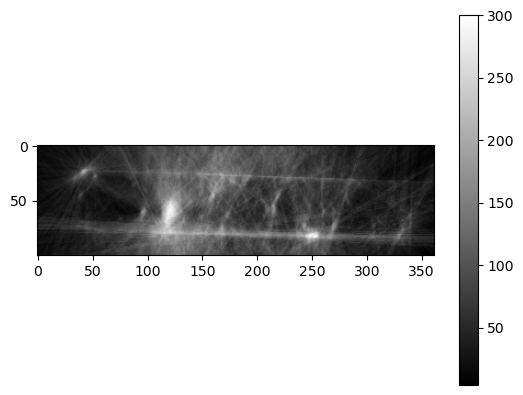

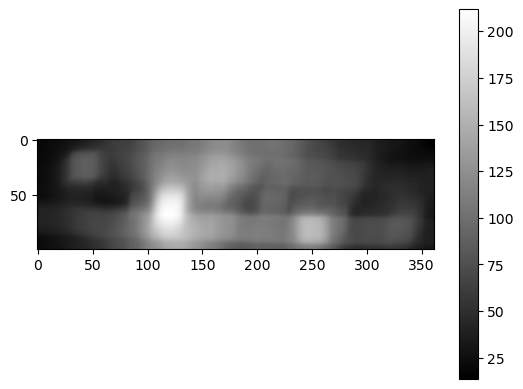

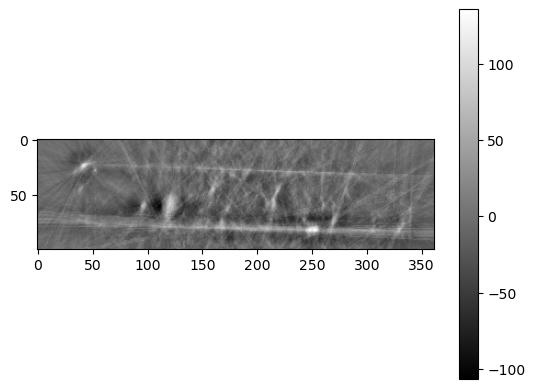

In [96]:
def intersect(f,N):
    return np.sum(f, axis=1)>N

f = out_recon
f_i = intersect(f,1.5)*1.0
f_t = np.sum(f_i,axis=0)
print(f_i.dtype)
f_s = self_convolve_normalized(f_t, 25)
plt.imshow(f_t)
plt.colorbar()
plt.show()

plt.imshow(f_s)
plt.colorbar()
plt.show()

plt.imshow(f_t-f_s)
plt.colorbar()
plt.show()

In [97]:
voter = np.sum(out_recon,axis=1)>4
out_recon_voter = out_recon_fbp*voter

In [147]:
import numpy as np
from scipy.ndimage import convolve
from scipy.ndimage import convolve, rotate

def estimate_line_angle_pca(image):
    # Threshold to find pixels that belong to the line
    y, x = np.nonzero(image > np.percentile(image, 95))  # top 5% intensity pixels
    
    coords = np.column_stack((x, y)).astype(np.float32)  # Convert to float for subtraction

    # Center the coordinates
    coords -= coords.mean(axis=0)

    # Compute PCA
    cov = np.cov(coords.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    direction = eigvecs[:, np.argmax(eigvals)]

    angle_rad = np.arctan2(-direction[1], direction[0])  # y, x
    angle_deg = np.degrees(angle_rad)
    
    return angle_deg


def oriented_gaussian_kernel(size, angle_deg, sigma_along=None, sigma_perp=1.0):
    assert size % 2 == 1, "Kernel size must be odd"
    if sigma_along is None:
        sigma_along = size / 3

    half = size // 2
    x = np.linspace(-half, half, size)
    y = np.linspace(-half, half, size)
    xx, yy = np.meshgrid(x, y)

    kernel = np.exp(-(xx**2 / (2 * sigma_along**2) + yy**2 / (2 * sigma_perp**2)))
    kernel /= kernel.sum()

    rotated_kernel = rotate(kernel, angle=-angle_deg, reshape=False, mode='nearest')
    rotated_kernel /= rotated_kernel.sum()
    return rotated_kernel



def directional_line_filter(f, masks, angles, kernel_size=15, sigma_perp=1.0):
    """
    f: (H, W) input image
    masks: (N, H, W) boolean arrays
    angles: list of N angles in degrees
    Returns: (H, W) filtered image
    """
    N, H, W = masks.shape
    assert f.shape == (H, W)

    filtered_images = np.zeros((N, H, W), dtype=np.float32)

    # 1. Apply each directional filter to the whole image
    for k in range(N):
        kernel = oriented_gaussian_kernel(kernel_size, angles[k], sigma_perp=sigma_perp)
        filtered_images[k] = convolve(f, kernel, mode='reflect')

    # 2. Weighted combination based on masks
    masks_float = masks.astype(np.float32)
    masked_filtered = filtered_images * masks_float  # only keep values where mask is True
    weights = masks_float.sum(axis=0)  # how many masks are True at each pixel

    # Avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        output = masked_filtered.sum(axis=0) / (weights + 1e-6)

    return output, kernel


In [108]:
angle_deg = np.zeros((nc, nl))
for il in range(nl):
    for ic in range(20,nc):
        angle_deg[ic, il] = estimate_line_angle_pca((f[ic,il]).astype(np.float32))


/tmp/ipykernel_3928909/419550598.py:12: RuntimeWarning: Mean of empty slice.
  coords -= coords.mean(axis=0)
/tmp/ipykernel_3928909/419550598.py:15: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov = np.cov(coords.T)


In [178]:
from scipy.ndimage import gaussian_filter
f_i = intersect(f,6.5)*1.0
N = 50
masks = (f>0)#*f_i[:,np.newaxis]
masks = masks.reshape(nc* nl, ny, nx)
angles = angle_deg.reshape(nc*nl)
indices = np.random.choice(nc*nl, size=500, replace=False)
angles_c = angles[indices]
masks_c = masks[indices]
image = np.sum(f_i>0,axis=0)
filtered,kernel = directional_line_filter(image, masks_c, angles_c, kernel_size=11, sigma_perp=1)

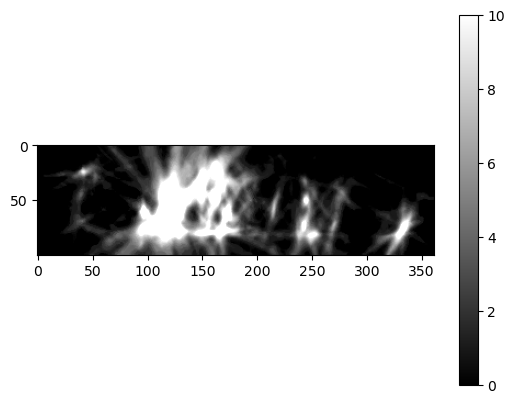

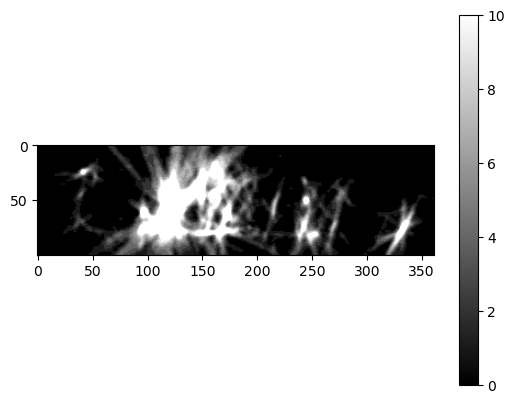

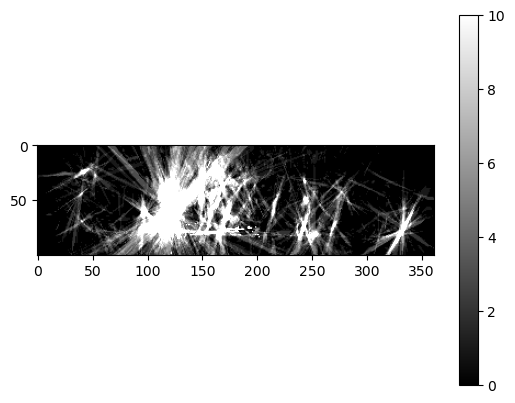

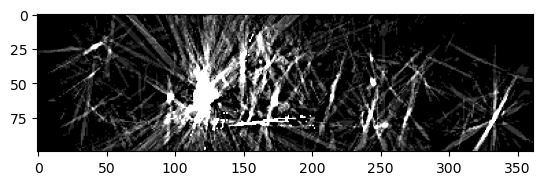

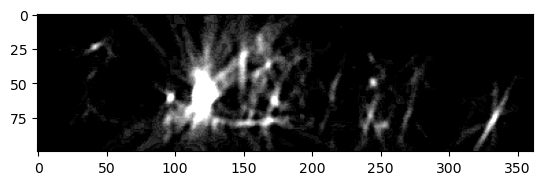

In [183]:

standard_filtered = gaussian_filter(image, sigma=1.5, mode='reflect')
plt.imshow(filtered)
plt.clim([0,10])
plt.colorbar()
plt.show()


plt.imshow(standard_filtered)
plt.clim([0,10])
plt.colorbar()
plt.show()


plt.imshow(image)
plt.clim([0,10])
plt.colorbar()
plt.show()

plt.imshow(1.4*image-filtered)
plt.clim([0,10])
plt.show()

plt.imshow(1.4*standard_filtered - filtered)
plt.clim([0,10])
plt.show()

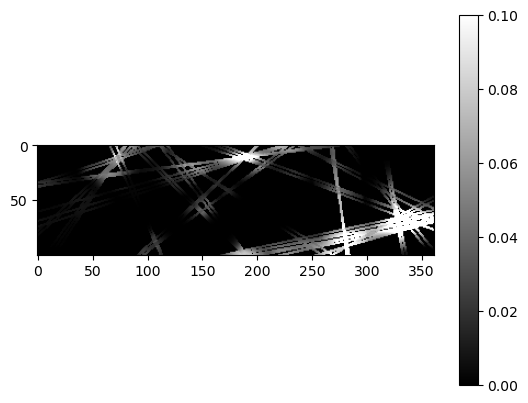

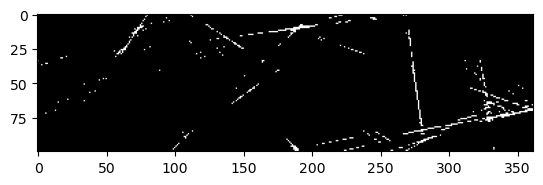

In [112]:
plt.imshow(filtered)
plt.clim([0,0.1])
plt.colorbar()
plt.show()

plt.imshow(f_i[N])
plt.show()

/tmp/ipykernel_3928909/56632630.py:12: RuntimeWarning: Mean of empty slice.
  coords -= coords.mean(axis=0)
/tmp/ipykernel_3928909/56632630.py:15: RuntimeWarning: Degrees of freedom <= 0 for slice
  cov = np.cov(coords.T)


float64


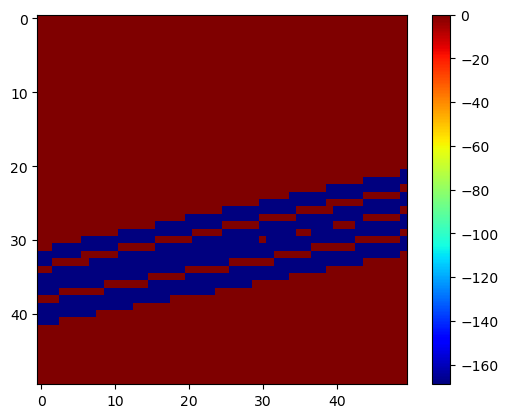

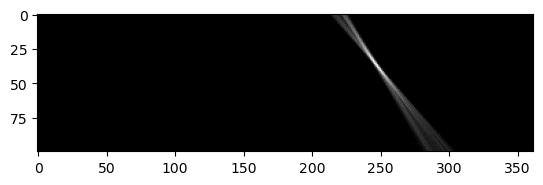

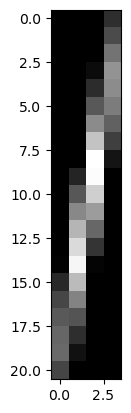

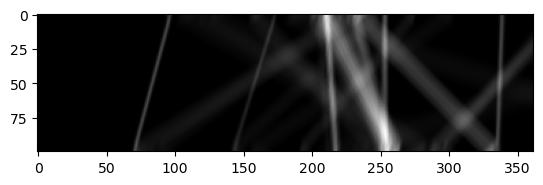

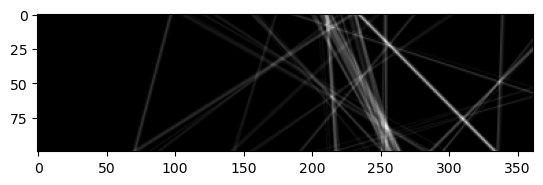

In [80]:
N = 350
nc, nl, ny, nx = np.shape(f)
f_angle = np.zeros_like(f)
for il in range(nl):
    for ic in range(20,nc-600):
        angle_deg = estimate_line_angle_pca((f[ic,il]>0).astype(np.float32))
        f_angle[ic,il] = (f[ic,il]>0)*angle_deg
print(f[50,0,80:100,250:300].dtype)

plt.imshow(f_angle[50,0,50:100,250:300], cmap='jet')
plt.colorbar()
plt.show()

kernel = oriented_gaussian_kernel(21, angle_deg, sigma_perp=0.1)
plt.imshow(out_recon[N,0])
plt.show()
plt.imshow(kernel)
plt.show()
smoothed = convolve(np.sum(out_recon_intensity[260],axis=0), kernel, mode='reflect')
plt.imshow(smoothed)
plt.show()
plt.imshow(np.sum(out_recon_intensity[260],axis=0))
plt.show()

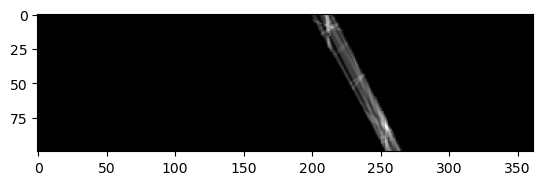

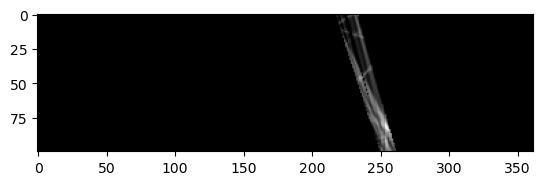

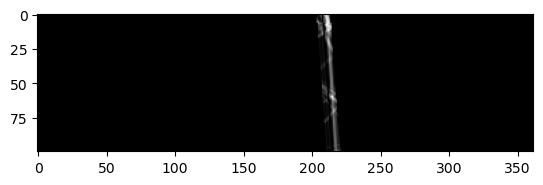

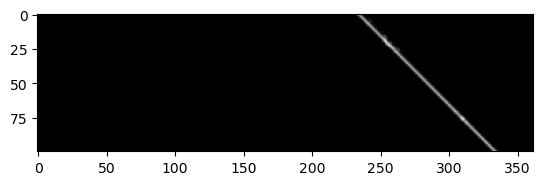

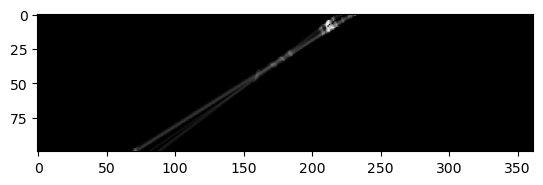

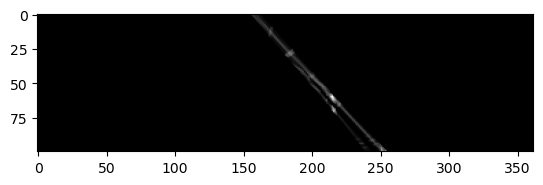

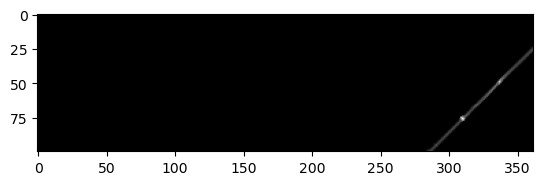

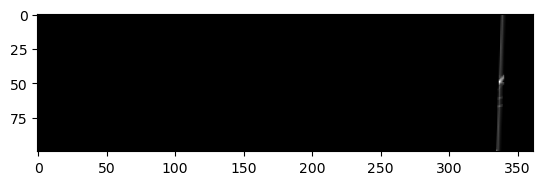

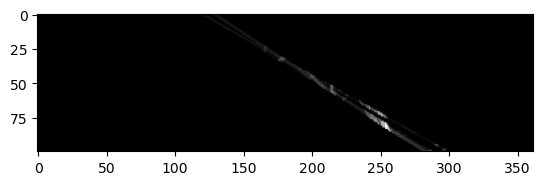

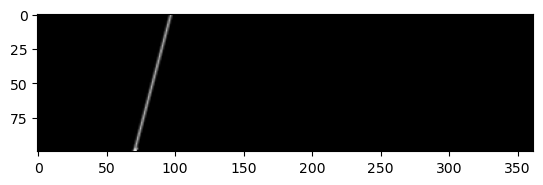

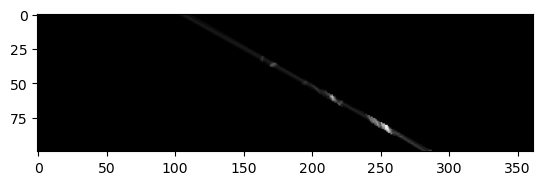

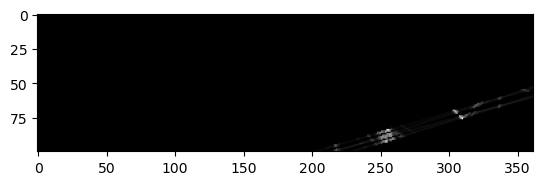

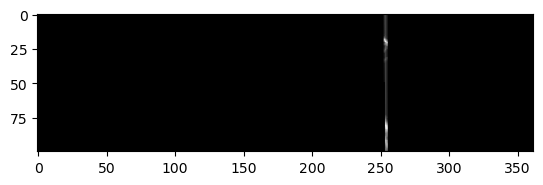

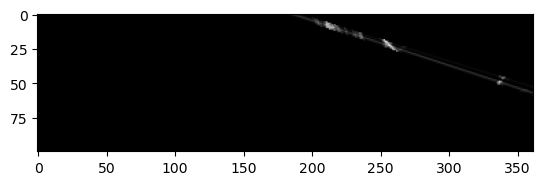

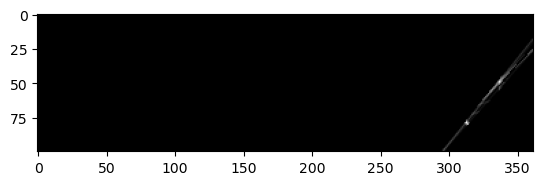

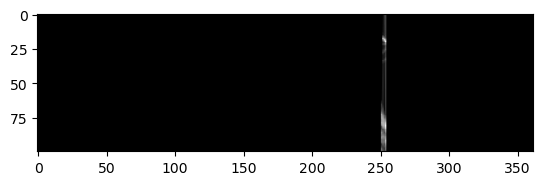

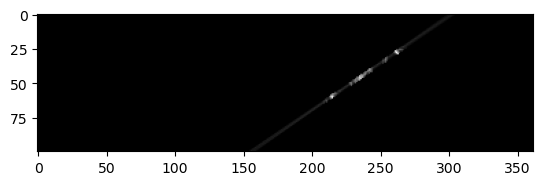

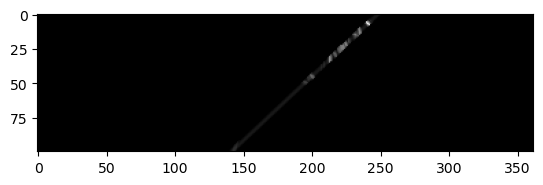

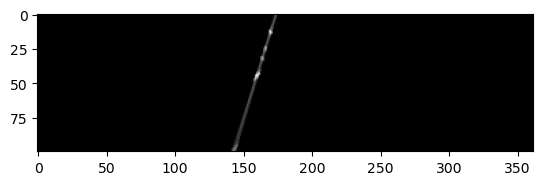

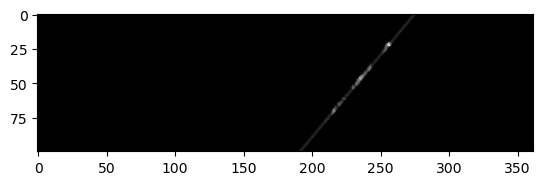

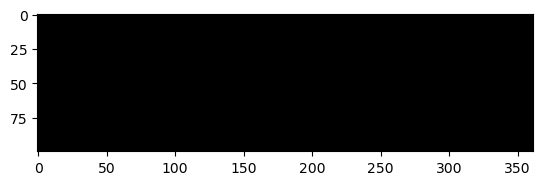

In [149]:
out_means = np.zeros_like(out_recon)
for i in range(20):
    out_means[260,i] = np.sum(out_recon_intensity[260,:],axis=0)[out_recon[260,i].astype(bool)].mean()

    plt.imshow(np.sum(out_recon_intensity[260,:],axis=0)*out_recon[260,i].astype(bool)-out_means[260,i])
    plt.show()

plt.imshow(out_means[260,0])
plt.show()

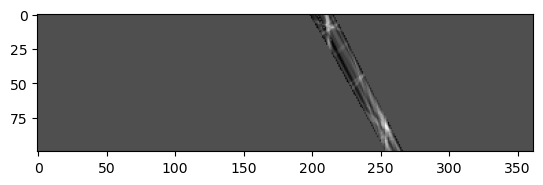

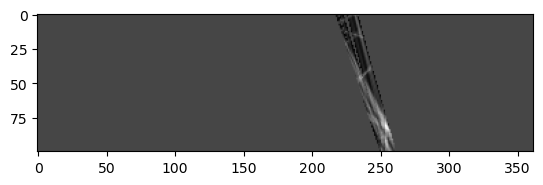

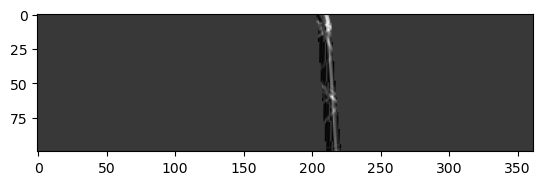

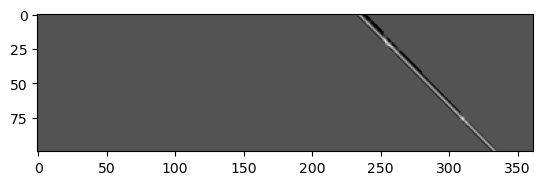

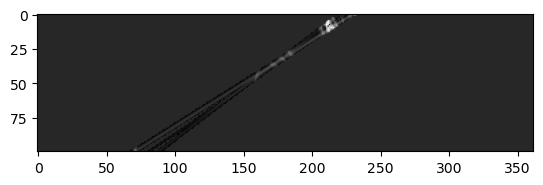

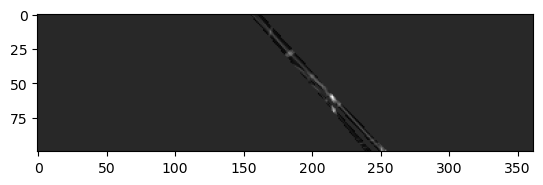

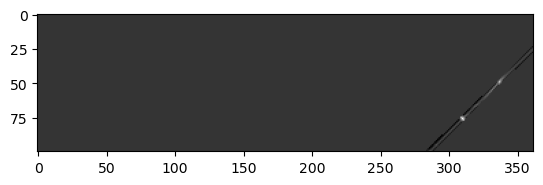

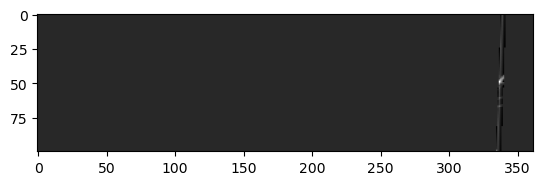

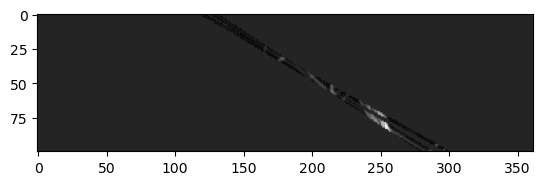

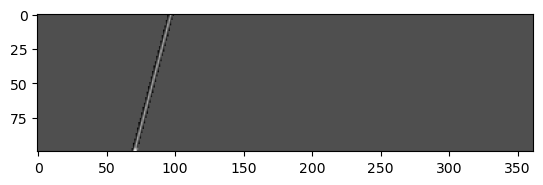

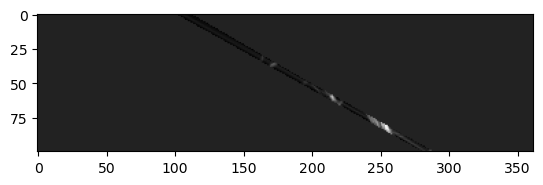

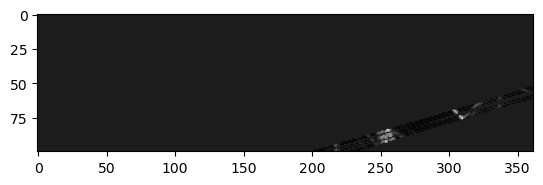

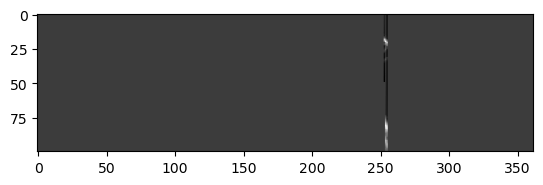

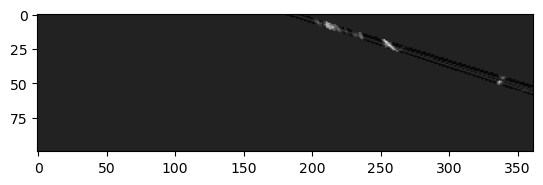

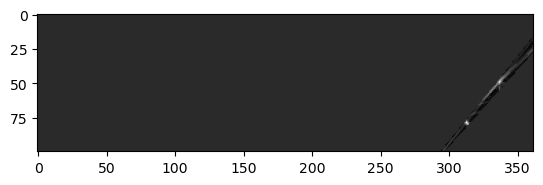

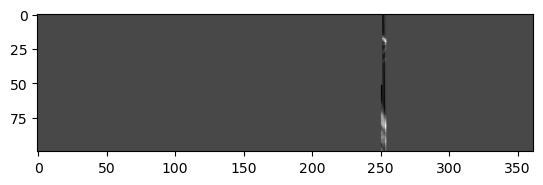

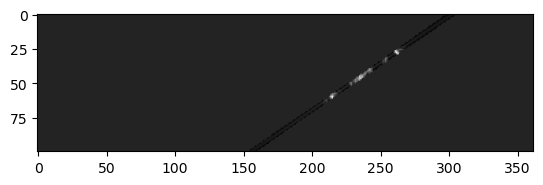

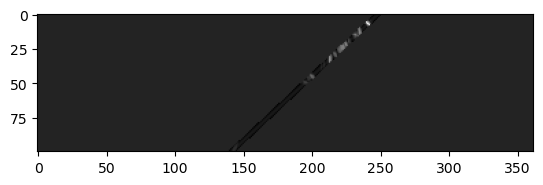

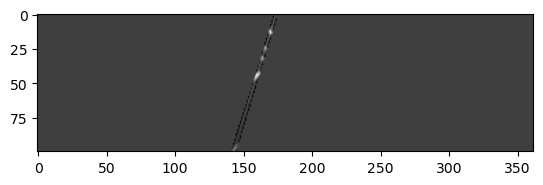

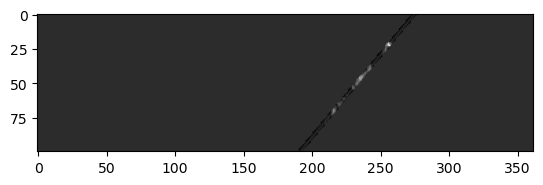

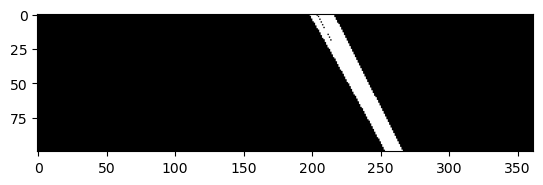

In [148]:
out_means = np.zeros_like(out_recon)
for i in range(20):
    out_means[260,i][out_recon[260,i].astype(bool)] = np.sum(out_recon_intensity[260,:],axis=0)[out_recon[260,i].astype(bool)].mean()

    plt.imshow(np.sum(out_recon_intensity[260,:],axis=0)*out_recon[260,i].astype(bool)-out_means[260,i])
    plt.show()

plt.imshow(out_means[260,0])
plt.show()

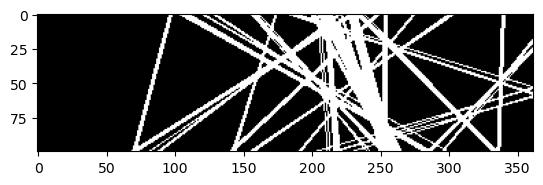

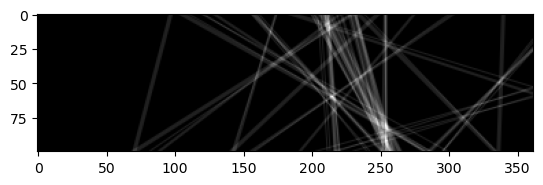

In [128]:
plt.imshow(np.sum(out_recon,axis=1)[260]>0.5)
plt.show()
plt.imshow(np.sum(out_recon,axis=1)[260])
plt.show()

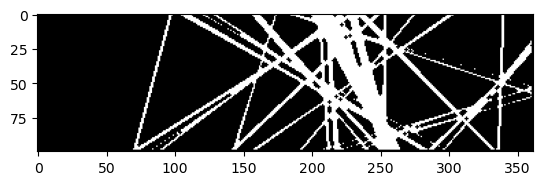

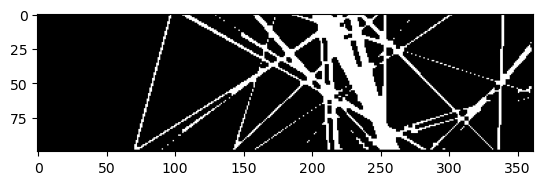

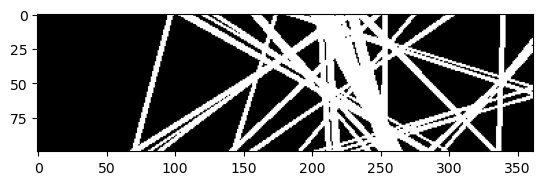

In [117]:
from scipy.ndimage import binary_erosion
eroded = binary_erosion(np.sum(out_recon,axis=1)[260]>0)

# If you want a custom structuring element:
from scipy.ndimage import generate_binary_structure
plt.imshow(eroded)
plt.show()

structure = generate_binary_structure(2, 5)  # 2D, 4-connected
eroded = binary_erosion(np.sum(out_recon,axis=1)[260], structure=structure)
plt.imshow(eroded)
plt.show()

plt.imshow(np.sum(out_recon,axis=1)[260]>0)
plt.show()

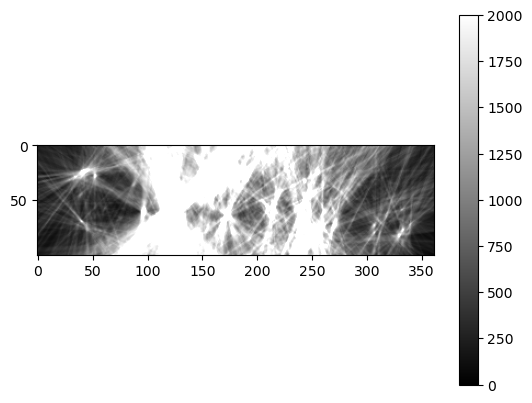

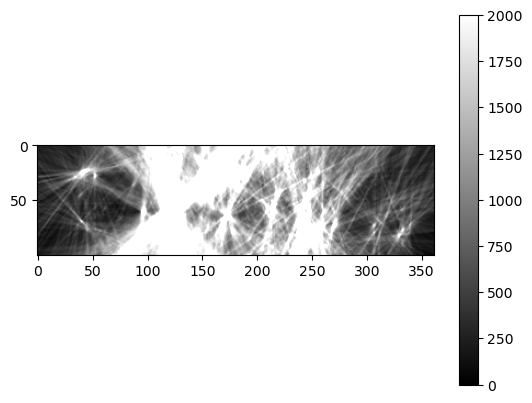

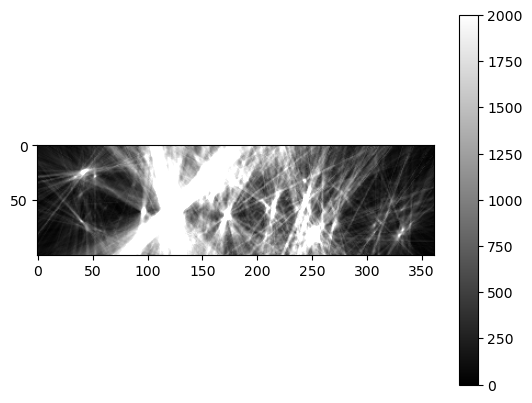

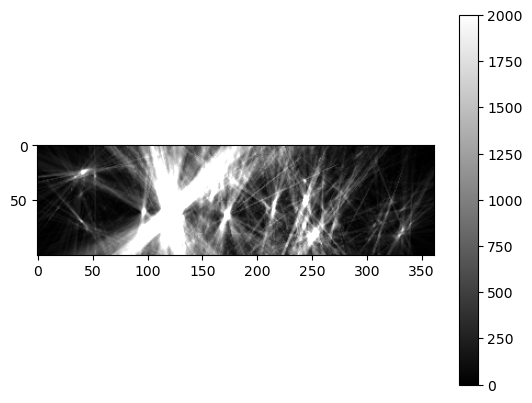

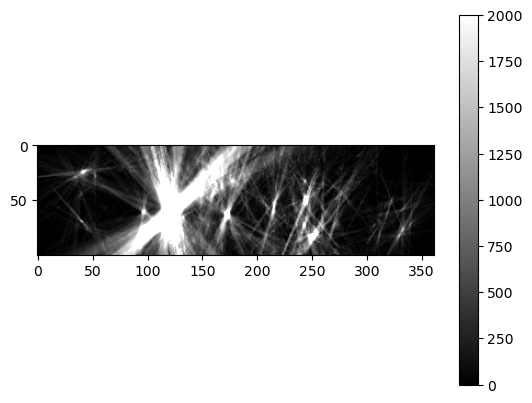

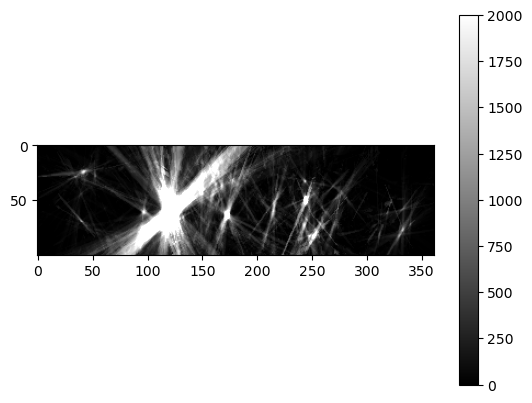

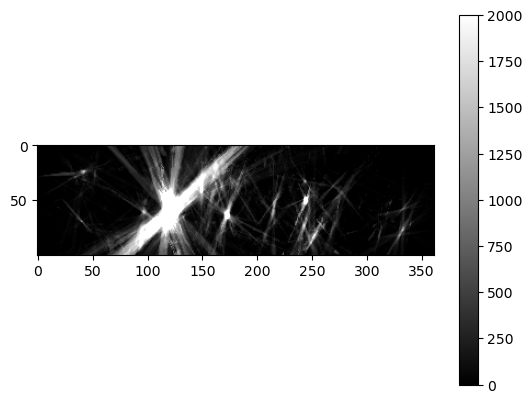

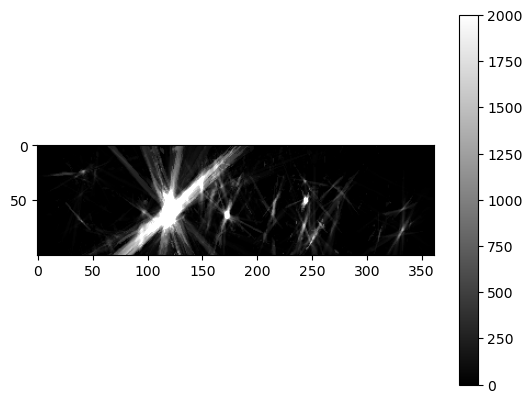

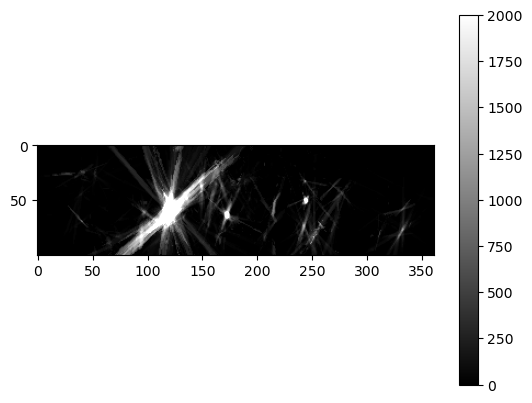

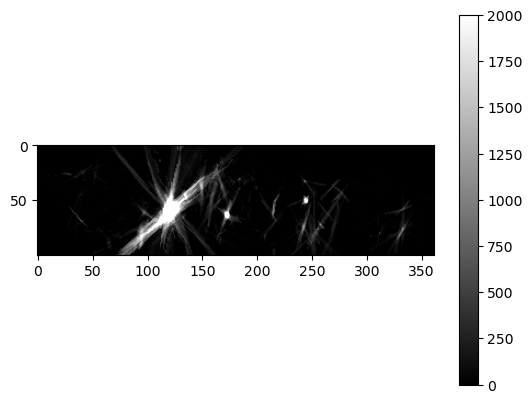

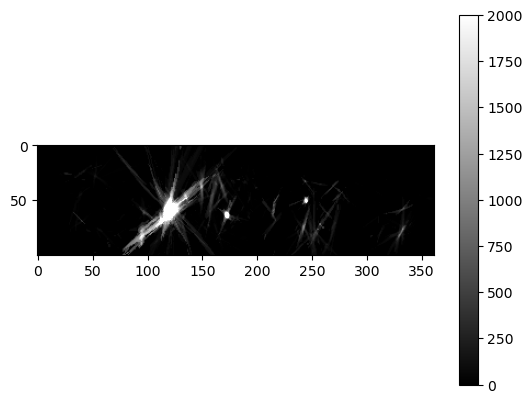

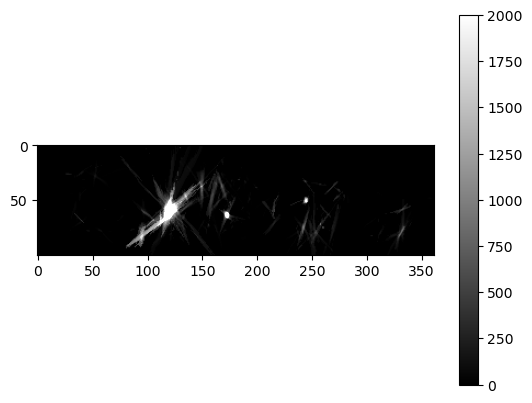

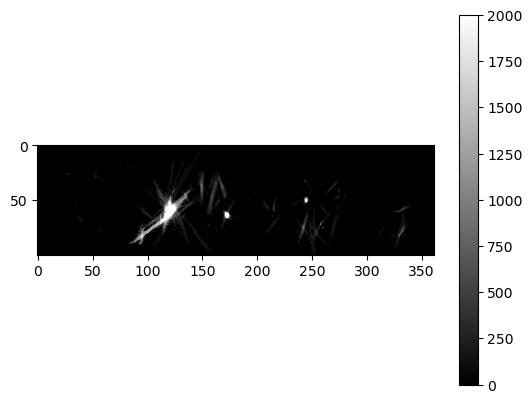

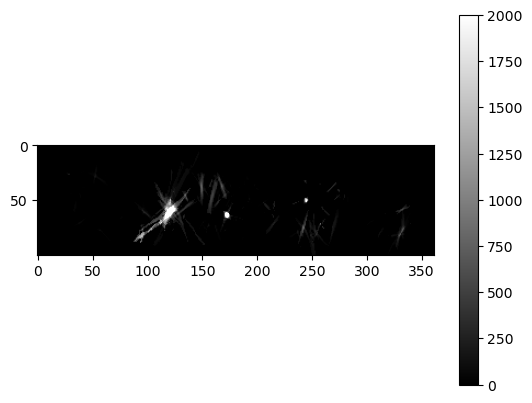

In [96]:
chan = 260

for i in range(14):
    plt.imshow(np.sum(out_recon_intensity*(np.sum(out_recon,axis=1)>-0.5+i)[:,np.newaxis],axis=(0,1)))
    plt.clim([0,2000])
    plt.colorbar()
    plt.show()


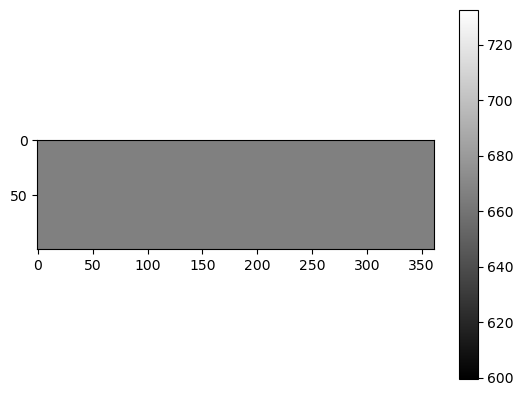

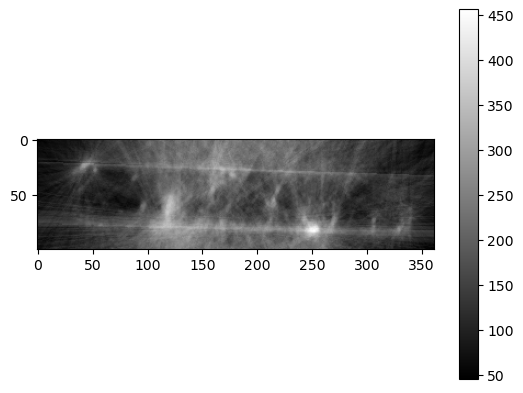

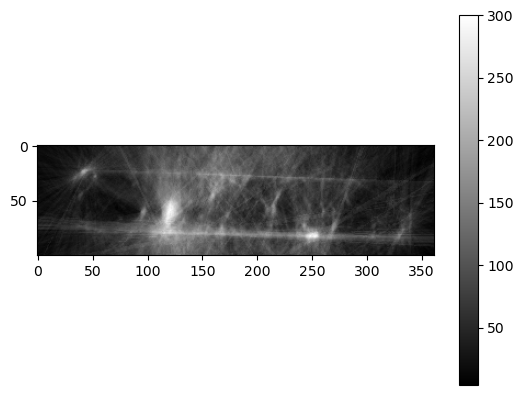

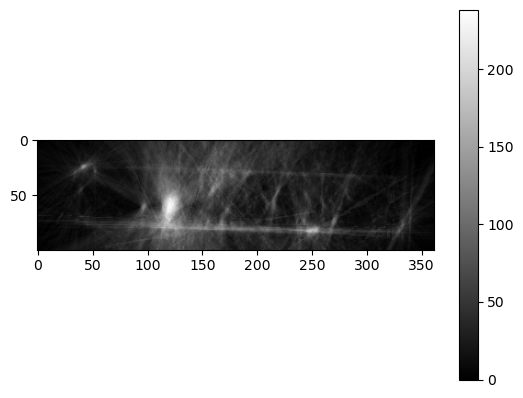

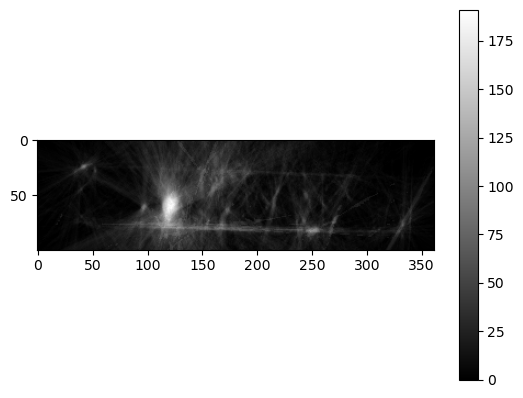

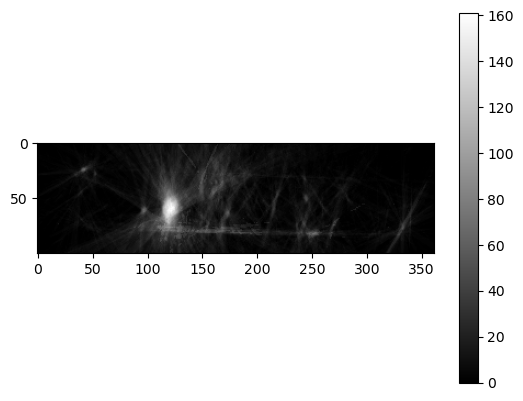

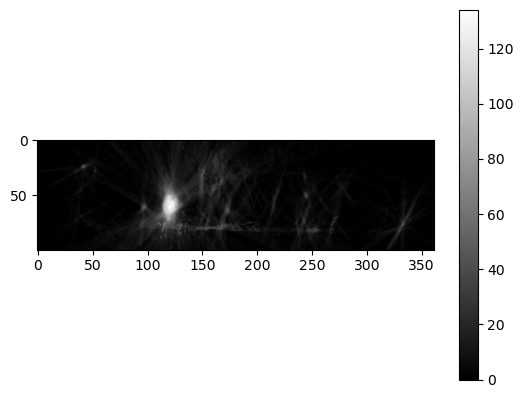

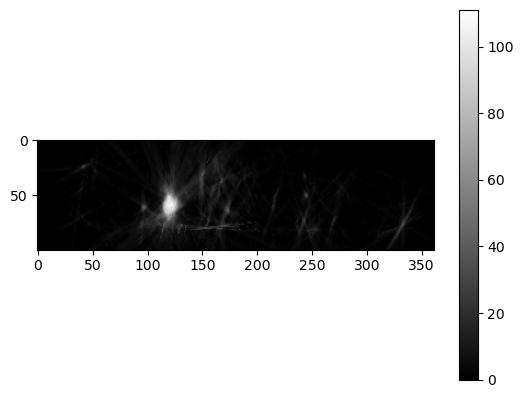

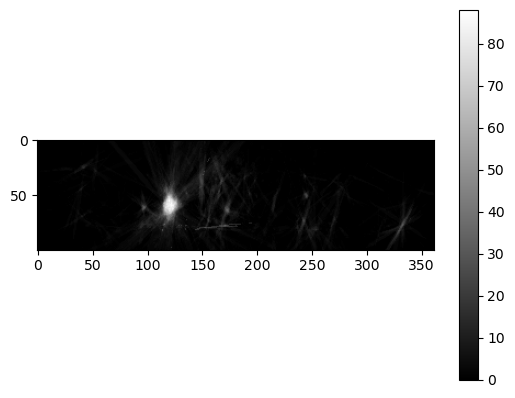

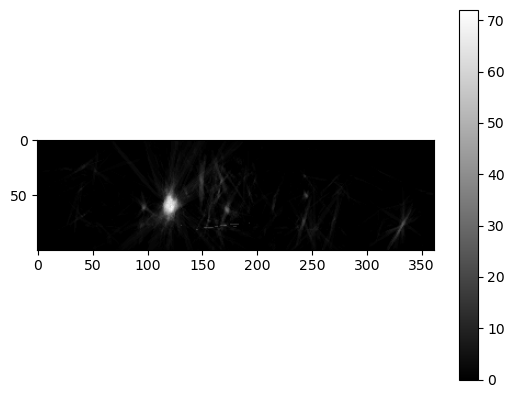

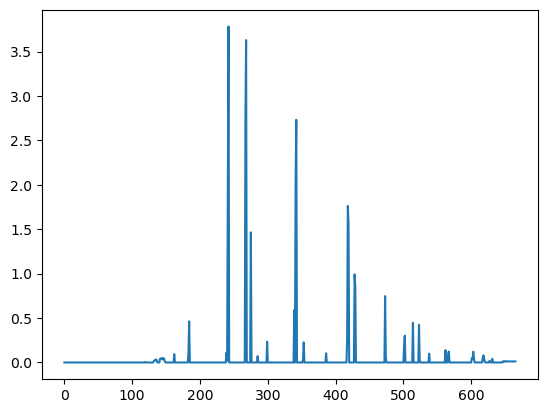

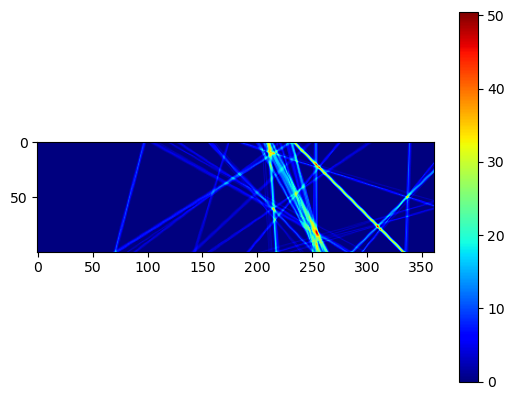

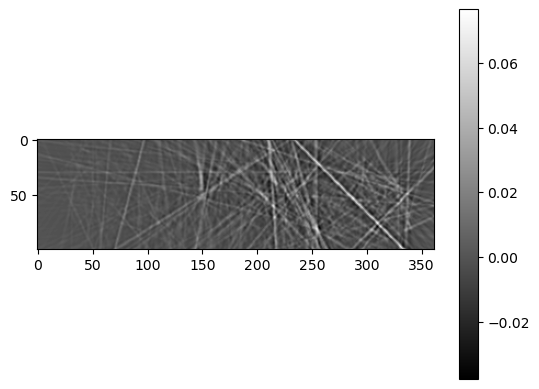

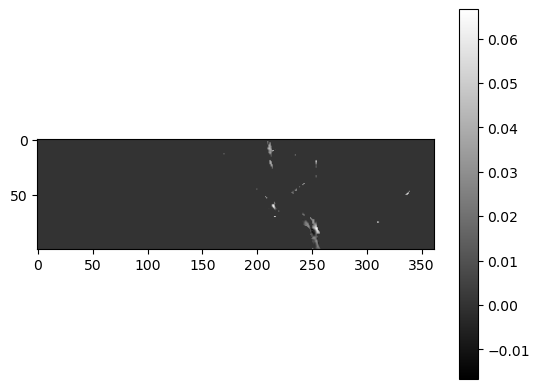

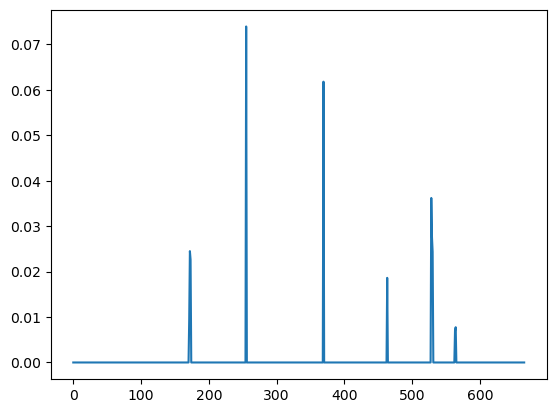

In [95]:

for i in range(10):
    plt.imshow(np.sum((np.sum(out_recon,axis=1)>-0.5+i)[:,np.newaxis],axis=(0,1)))
    plt.colorbar()
    plt.show()




q = np.quantile(np.sum(out_recon_intensity[:], axis=1), q=0.6,axis=[1,2])
plt.plot(q)
plt.show()

plt.imshow(np.sum(out_recon_intensity[chan,:], axis=0),cmap='jet')
plt.colorbar()
plt.show()

plt.imshow(out_recon_fbp[chan])
plt.colorbar()
plt.show()


plt.imshow(out_recon_voter[chan])
plt.colorbar()
plt.show()

plt.plot(out_recon_voter[:,50, 200])
plt.show()


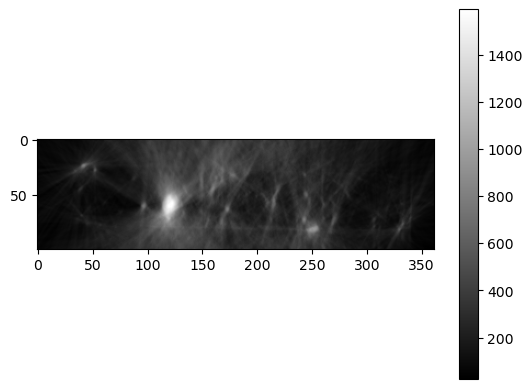

In [102]:
plt.imshow(np.sum(np.log1p(np.sum(out_recon_intensity,axis=1))*np.log1p(np.sum(out_recon,axis=1)),axis=0))
#plt.clim([0,2000])
plt.colorbar()
plt.show()

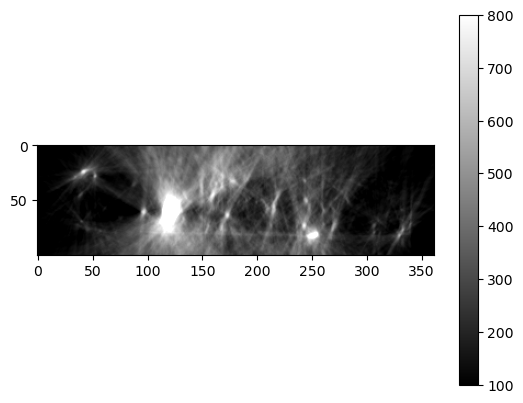

In [109]:
plt.imshow(np.sum(np.log1p(np.sum(out_recon_intensity,axis=1))*np.log1p(np.sum(out_recon,axis=1)),axis=0))
plt.clim([100,800])
plt.colorbar()
plt.show()

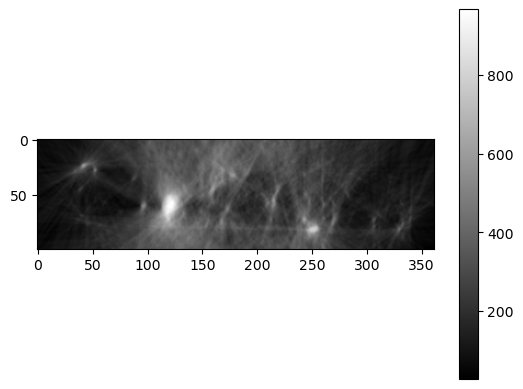

In [105]:
plt.imshow(np.sum(np.log1p(np.sum(out_recon_intensity,axis=1)*np.log1p(np.sum(out_recon,axis=1))),axis=0))
#plt.clim([0,2000])
plt.colorbar()
plt.show()